In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = r"/content/drive/MyDrive/news_articles.csv"
data = pd.read_csv(file_path)

In [4]:
!unzip /content/drive/MyDrive/drug_review_test.csv.zip

Archive:  /content/drive/MyDrive/drug_review_test.csv.zip
  inflating: drug_review_test.csv    


* IMPORT ALL REQUIRED LIBRARIES

In [5]:
# Basic libraries
import pandas as pd
import numpy as np

In [6]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Text preprocessing libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [9]:
# BERT related libraries
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import Trainer, TrainingArguments

import torch
from torch.utils.data import Dataset

nltk.download('stopwords')
nltk.download('wordnet')

sns.set(style="whitegrid")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [10]:
# Handle warning
import warnings
warnings.filterwarnings("ignore")

In [11]:
# Load the dataset
df = pd.read_csv("drug_review_test.csv")

In [12]:
# Display first few rows
print("First 5 rows of dataset:")
df.head()

First 5 rows of dataset:


,Unnamed: 0,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,0,163740,Mirtazapine,depression,"""i've tried a few antidepressants over the yea...",10.0,"February 28, 2012",22,68
1,1,206473,Mesalamine,"crohn's disease, maintenance","""my son has crohn's disease and has done very ...",8.0,"May 17, 2009",17,48
2,2,39293,Contrave,weight loss,"""contrave combines drugs that were used for al...",9.0,"March 5, 2017",35,143
3,3,97768,Cyclafem 1 / 35,birth control,"""i have been on this birth control for one cyc...",9.0,"October 22, 2015",4,149
4,4,208087,Zyclara,keratosis,"""4 days in on first 2 weeks. using on arms an...",4.0,"July 3, 2014",13,60


In [13]:
# Dataset shape
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(46108, 9)


In [14]:
# Data columns
print("Dataset Columns:")
df.columns

Dataset Columns:


Index(['Unnamed: 0', 'patient_id', 'drugName', 'condition', 'review', 'rating',
       'date', 'usefulCount', 'review_length'],
      dtype='object')

In [15]:
# Dataset information
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46108 entries, 0 to 46107
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     46108 non-null  int64  
 1   patient_id     46108 non-null  int64  
 2   drugName       46108 non-null  object 
 3   condition      46108 non-null  object 
 4   review         46108 non-null  object 
 5   rating         46108 non-null  float64
 6   date           46108 non-null  object 
 7   usefulCount    46108 non-null  int64  
 8   review_length  46108 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 3.2+ MB


In [16]:
# Check Missing Values
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
Unnamed: 0,0
patient_id,0
drugName,0
condition,0
review,0
rating,0
date,0
usefulCount,0
review_length,0


In [17]:
# Dataset summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Unnamed: 0,patient_id,rating,usefulCount,review_length
count,46108.000000,46108.000000,46108.000000,46108.000000,46108.000000
mean,4741.710289,116604.217988,6.980979,28.505270,95.415156
std,2841.941628,66906.119983,3.256990,37.222459,37.716939
min,0.000000,0.000000,1.000000,0.000000,31.000000
25%,2305.000000,59070.750000,5.000000,6.000000,63.000000
50%,4610.000000,116932.500000,8.000000,16.000000,95.000000
75%,7118.000000,174279.000000,10.000000,37.000000,130.000000
max,9999.000000,232284.000000,10.000000,949.000000,1162.000000


In [18]:
# Check number of unique drugs
print("Unique Drugs:", df['drugName'].nunique())

Unique Drugs: 2283


In [19]:
# Check number of conditions
print("Unique Conditions:", df['condition'].nunique())

Unique Conditions: 652


#### Data Processing

In [20]:
# Drop unnecessary columns
df = df.drop(['Unnamed: 0', 'patient_id', 'date'], axis=1)

In [21]:
# Convert rating into sentiment classes
def convert_sentiment(rating):

    if rating <= 4:
        return "Negative"

    elif rating <= 6:
        return "Neutral"

    else:
        return "Positive"

df['sentiment'] = df['rating'].apply(convert_sentiment)

In [22]:
# Check class distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

Sentiment Distribution:
sentiment
Positive    30409
Negative    11445
Neutral      4254
Name: count, dtype: int64


##### EXPLORATORY DATA ANALYSIS

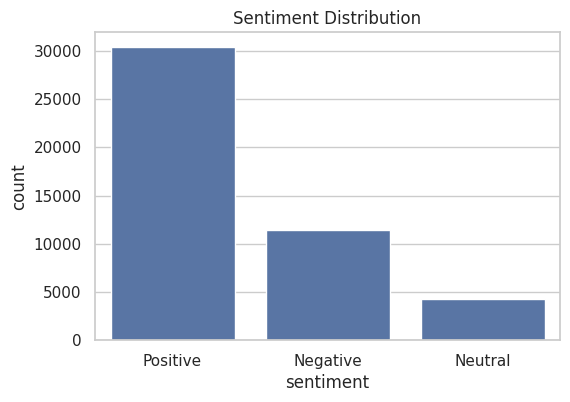

In [23]:
# Graph 1: Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

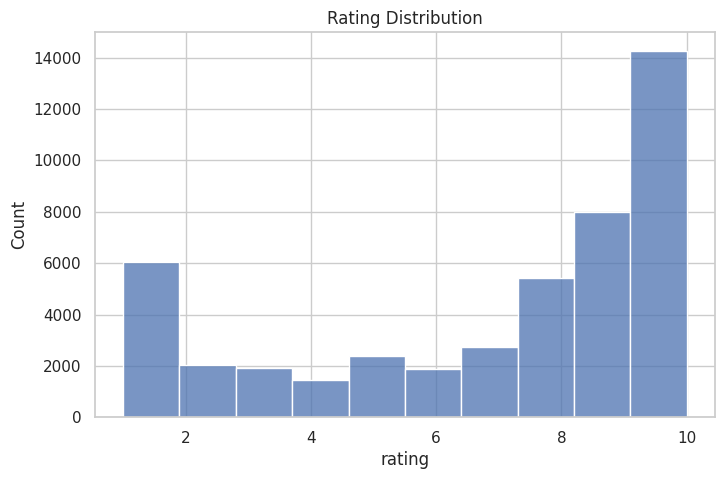

In [24]:
# Graph 2: Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

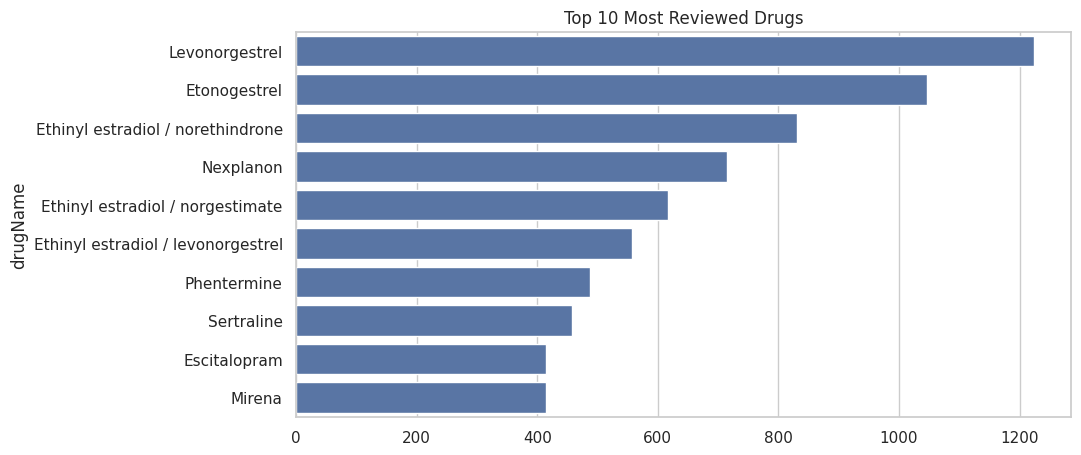

In [25]:
# Graph 3: Top 10 Reviewed Drugs
top_drugs = df['drugName'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_drugs.values, y=top_drugs.index)
plt.title("Top 10 Most Reviewed Drugs")
plt.show()

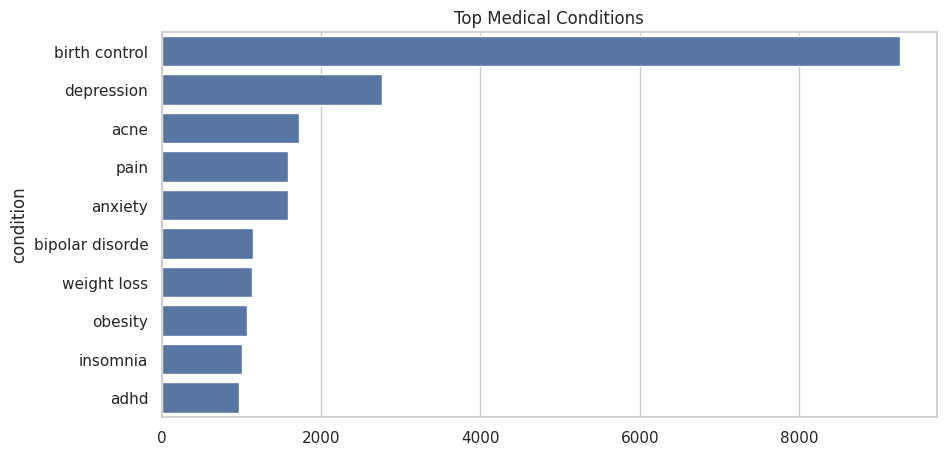

In [26]:
# Graph 4: Top Medical Conditions
top_conditions = df['condition'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_conditions.values, y=top_conditions.index)
plt.title("Top Medical Conditions")
plt.show()

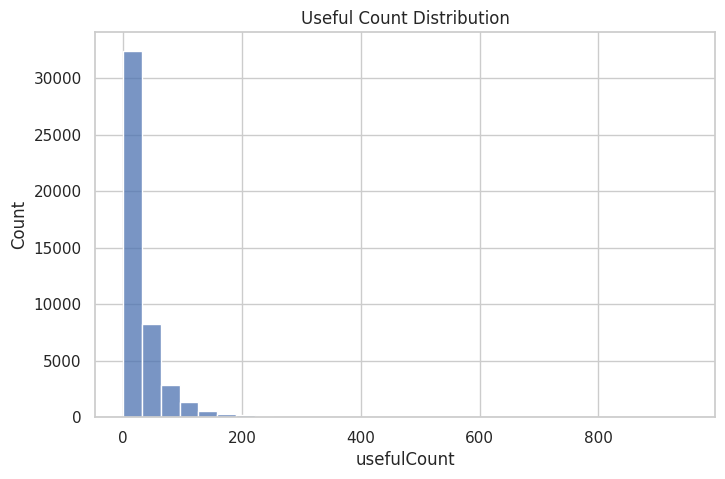

In [27]:
# Graph 5: Useful Count Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['usefulCount'], bins=30)
plt.title("Useful Count Distribution")
plt.show()

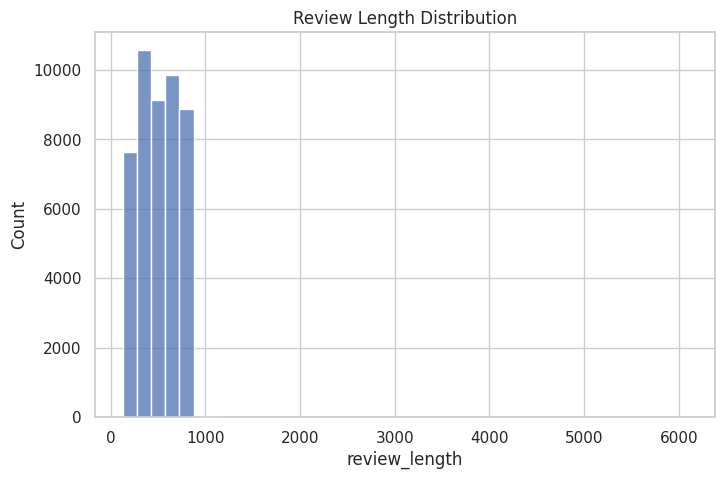

In [28]:
# Graph 6: Review Length Distribution
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['review_length'], bins=40)
plt.title("Review Length Distribution")
plt.show()

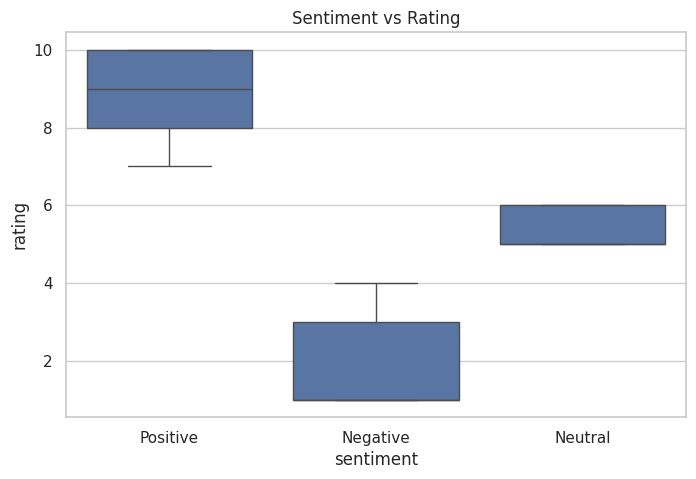

In [29]:
# Graph 7: Sentiment vs Rating
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='rating', data=df)
plt.title("Sentiment vs Rating")
plt.show()

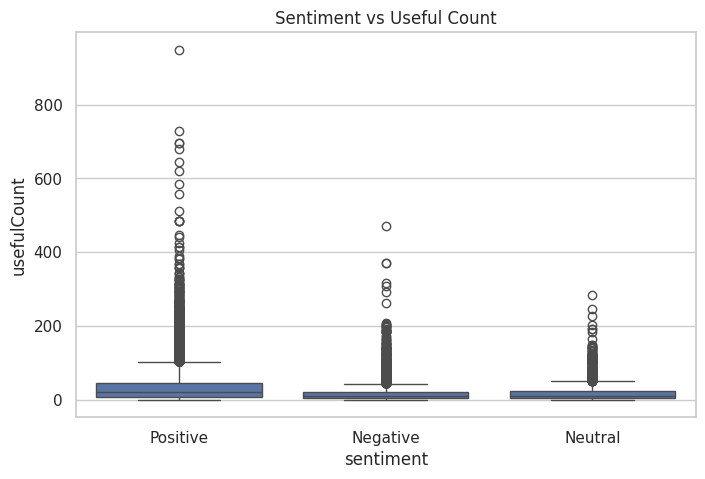

In [30]:
# Graph 8: Sentiment vs Useful Count
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='usefulCount', data=df)
plt.title("Sentiment vs Useful Count")
plt.show()

#### DATA PREPROCESSING AND FEATURE ENGINEERING

In [31]:
# Stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [32]:
# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

# Apply cleaning
df['clean_review'] = df['review'].apply(clean_text)

In [33]:
# Encode sentiment labels
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

In [34]:
# Train test split
X = df['clean_review']
y = df['sentiment_encoded']

In [35]:
# Split training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# TF-IDF Feature extraction
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#### MODEL BUILDING

* MODEL 1: LOGISTIC REGRESSION

In [37]:
# Load Model
lr_model = LogisticRegression(max_iter=1000)

In [38]:
# Model training
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [39]:
# Model testing
lr_pred = lr_model.predict(X_test_tfidf)

In [40]:
# Model Evluation
print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy: 0.7817176317501626


In [41]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.65      0.68      2342
           1       0.36      0.04      0.08       827
           2       0.81      0.93      0.87      6053

    accuracy                           0.78      9222
   macro avg       0.63      0.54      0.54      9222
weighted avg       0.74      0.78      0.75      9222



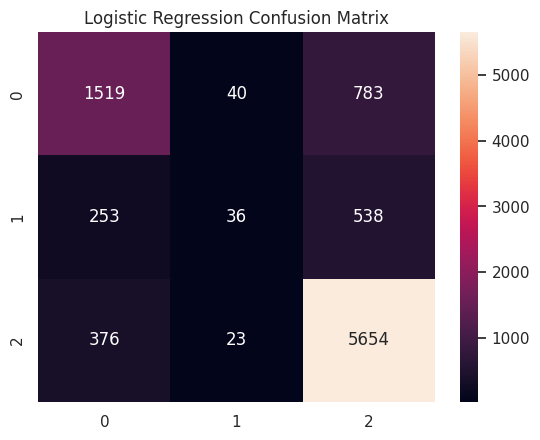

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### MODEL 2: DECISION TREE

In [43]:
# Load Model
dt_model = DecisionTreeClassifier()

In [44]:
# Model training
dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier()

In [45]:
# Model testing
dt_pred = dt_model.predict(X_test_tfidf)

In [46]:
# Model Evaluation
print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy: 0.6711125569290827


In [47]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52      2342
           1       0.28      0.27      0.27       827
           2       0.78      0.78      0.78      6053

    accuracy                           0.67      9222
   macro avg       0.53      0.52      0.53      9222
weighted avg       0.67      0.67      0.67      9222



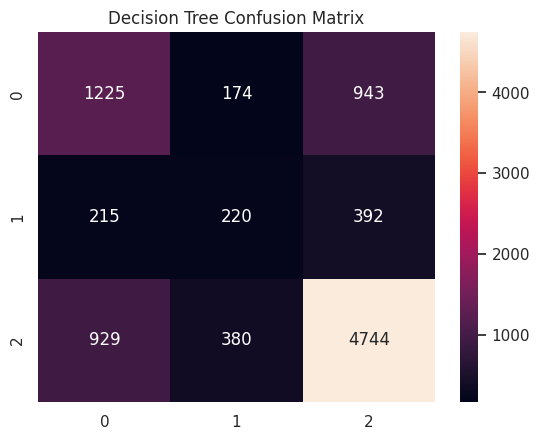

In [48]:
# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

#### MODEL 3: RANDOM FOREST

In [49]:
# Load Model
rf_model = RandomForestClassifier(n_estimators=100)

In [50]:
# Model Training
rf_model.fit(X_train_tfidf, y_train)

RandomForestClassifier()

In [51]:
# Model Testing
rf_pred = rf_model.predict(X_test_tfidf)

In [52]:
# Model Evaluation
print("\nRandom Forest Accuracy:", accuracy_score(y_test, rf_pred))


Random Forest Accuracy: 0.7666449793970939


In [53]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.41      0.55      2342
           1       1.00      0.17      0.29       827
           2       0.75      0.99      0.85      6053

    accuracy                           0.77      9222
   macro avg       0.87      0.52      0.57      9222
weighted avg       0.80      0.77      0.73      9222



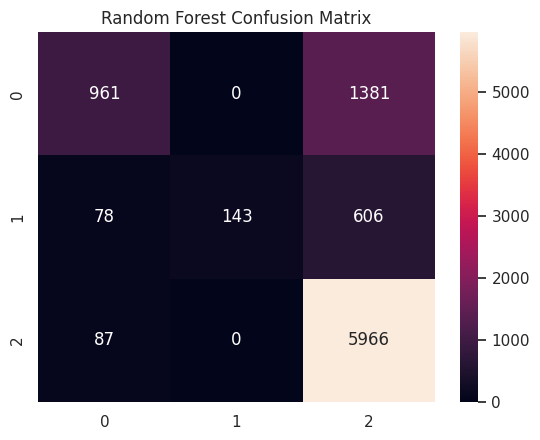

In [54]:
# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

#### BERT MODEL

In [55]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class DrugDataset(Dataset):

    def __init__(self, texts, labels):

        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding=True,
            max_length=128
        )

        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [56]:
train_dataset = DrugDataset(X_train, y_train)
test_dataset = DrugDataset(X_test, y_test)

In [57]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [58]:
# Training argument for BERT
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [59]:
# Model Training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset)

trainer.train()

Step,Training Loss
500,0.821451
1000,0.726821
1500,0.658106
2000,0.639465


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2306, training_loss=0.6998450286679958, metrics={'train_runtime': 866.2406, 'train_samples_per_second': 42.582, 'train_steps_per_second': 2.662, 'total_flos': 2426300381578752.0, 'train_loss': 0.6998450286679958, 'epoch': 1.0})

In [60]:
# Predictions
predictions = trainer.predict(test_dataset)
bert_pred = np.argmax(predictions.predictions, axis=1)

In [61]:
# Model Evaluation
print("\nBERT Accuracy:", accuracy_score(y_test, bert_pred))


BERT Accuracy: 0.7706571242680547


In [62]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, bert_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.68      0.67      2342
           1       0.00      0.00      0.00       827
           2       0.81      0.91      0.86      6053

    accuracy                           0.77      9222
   macro avg       0.49      0.53      0.51      9222
weighted avg       0.70      0.77      0.73      9222



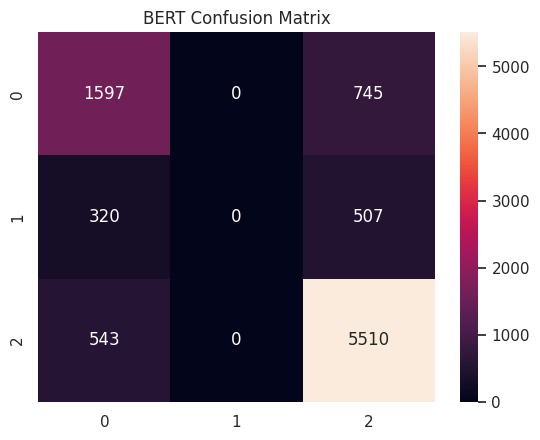

In [63]:
# Confusion Matrix
cm = confusion_matrix(y_test, bert_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("BERT Confusion Matrix")
plt.show()

* Model Comparision

In [64]:
# MODEL COMPARISON
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","BERT"],
    "Accuracy": [accuracy_score(y_test, lr_pred),accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),accuracy_score(y_test, bert_pred)]
})

print("Model Comparison:")
results

Model Comparison:


,Model,Accuracy
0,Logistic Regression,0.781718
1,Decision Tree,0.671113
2,Random Forest,0.766645
3,BERT,0.770657


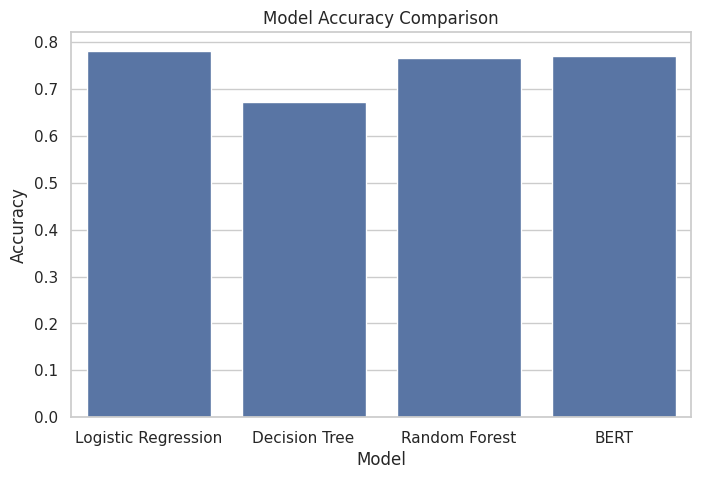

In [65]:
# Model Comparision graph
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title("Model Accuracy Comparison")
plt.show()